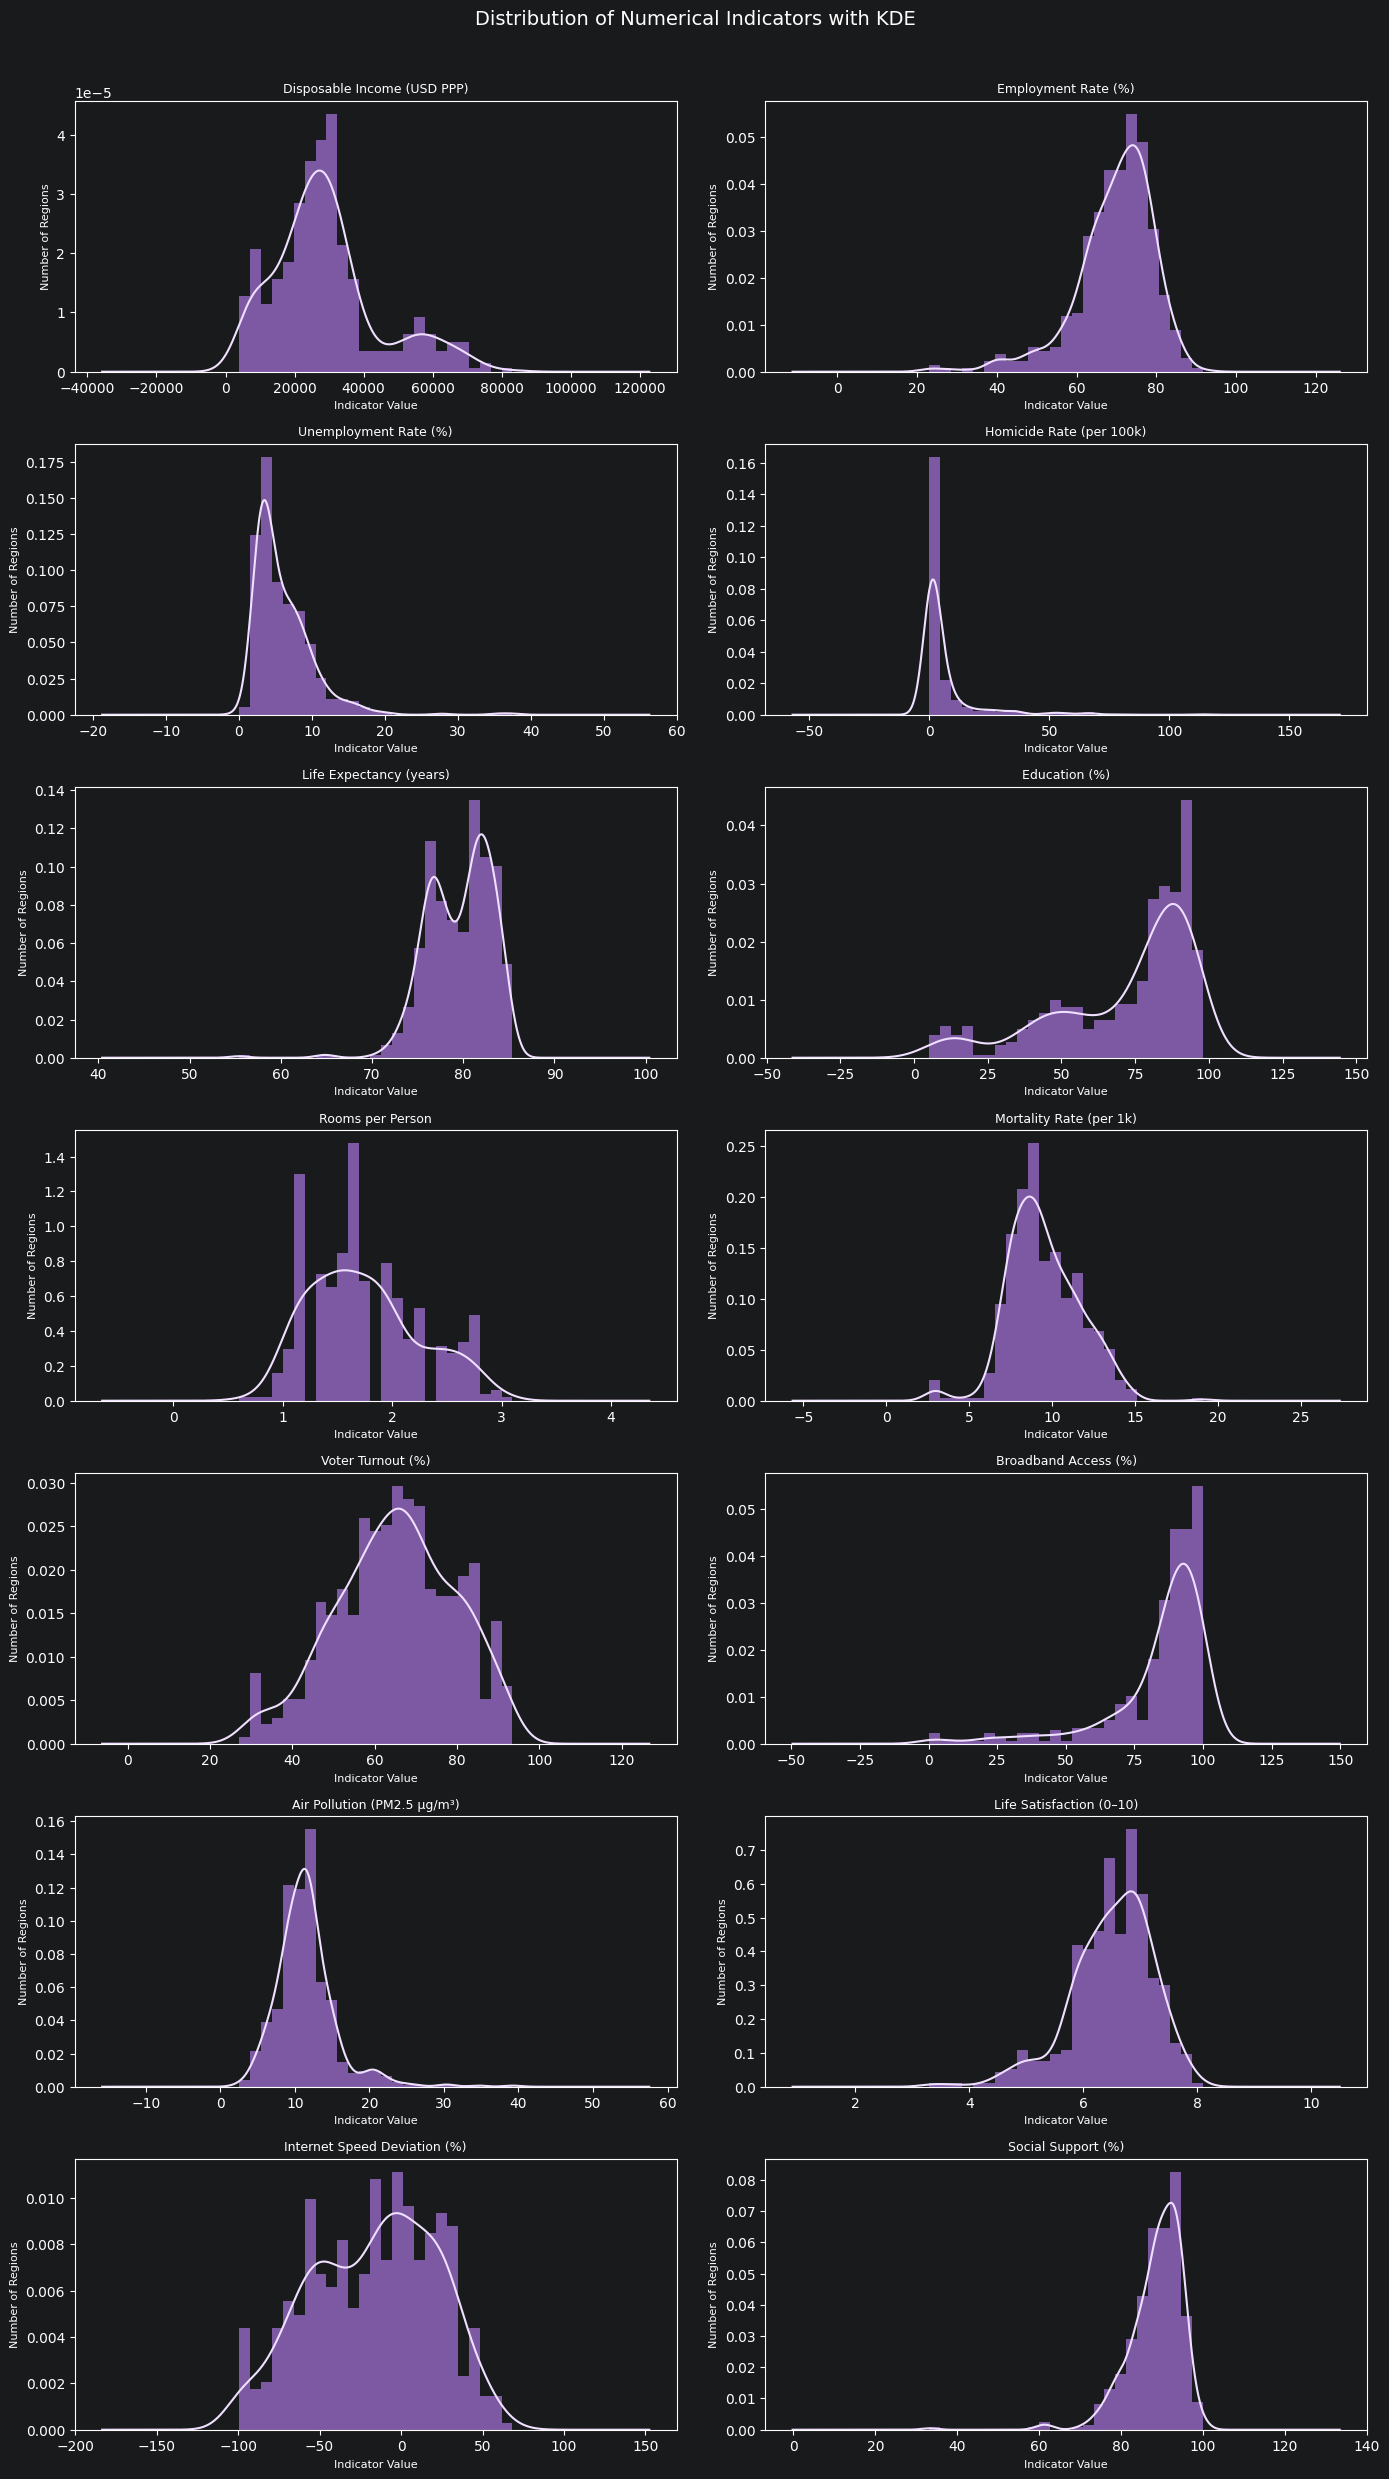

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from configs.config import PLOTS_DIR, DATA_PROCESSED_CSV_PATH

df = pd.read_csv('oecd_cleaned.csv')
numeric_cols = df.select_dtypes(include='number').columns.tolist()

os.makedirs(PLOTS_DIR, exist_ok=True)

# Create a grid of histograms with KDE overlaid
n_cols = 2
n_rows = (len(numeric_cols) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=25, color='#c084fc', alpha=0.6, density=True)
    data.plot.kde(ax=ax, color='#f0e0ff', linewidth=1.5)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('Indicator Value', fontsize=8)
    ax.set_ylabel('Number of Regions', fontsize=8)

# Hide any unused subplot panels
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Indicators with KDE', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('results/plots/01_distributions.png', dpi=150, bbox_inches='tight')
